# 04 · Seniority classifier

Predict **Entry / Mid / Senior** from a posting's title + description.

Training runs in `src/models/train_classifier.py` (`python -m src.models.train_classifier`). This notebook loads its outputs (`reports/metrics.json`, `models/*.joblib`, and the test-set predictions) and explains them.

**Evaluation design**
- **Grouped test split:** ~20% of postings, and no company appears in both train and test (`StratifiedGroupKFold` by company). Companies reuse templates, so a random split would let near-duplicates leak into the test set.
- **No leakage in features:** the TF-IDF vocabulary, imputer and scaler are fitted inside the Pipeline on training folds only. Each posting's own company name is removed from its text.
- **Model selection** uses 5-fold grouped CV on the training set. The test set is used once, at the end.
- **Main metric: macro F1**, the unweighted mean of per-class F1. Senior is 2.7% of the data, and accuracy would hide failing on it.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz

viz.set_style()
pd.set_option("display.max_colwidth", 120)

M = json.loads((ROOT / "reports" / "metrics.json").read_text())["seniority"]
W, NT = M["with_title"], M["without_title"]
CLASSES = M["classes"]
preds = pd.read_parquet(ROOT / "data" / "processed" / "seniority_test_predictions.parquet")
bundle = joblib.load(ROOT / "models" / "seniority.joblib")
model = bundle["pipeline"]
print("Final model:", W["model"], W["params"])
pd.Series(W["split"])

Final model: XGBoost {'clf__max_depth': 4}


train                                                    5686
test                                                     1422
train_companies                                          2196
test_companies                                            558
test_class_counts    {'Entry': 464, 'Mid': 920, 'Senior': 38}
dtype: object

## 1. Baseline and model comparison (5-fold grouped CV on the training set)

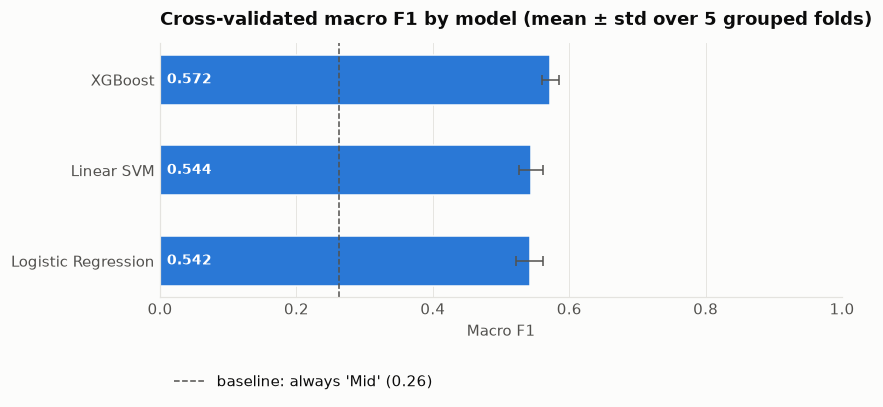

,cv_macro_f1_mean,cv_macro_f1_std,cv_balanced_acc_mean,seconds
model,,,,
XGBoost,0.572,0.013,0.537,485.408
Linear SVM,0.544,0.018,0.515,51.300
Logistic Regression,0.542,0.019,0.549,38.935


In [2]:
cv = pd.DataFrame(W["cv_comparison"]).set_index("model")
baseline_f1 = W["baseline_test"]["macro_f1"]

fig, ax = plt.subplots(figsize=(8, 3))
order = cv.sort_values("cv_macro_f1_mean").index
ax.barh(order, cv.loc[order, "cv_macro_f1_mean"], xerr=cv.loc[order, "cv_macro_f1_std"], color=viz.BLUE,
        height=0.55, edgecolor=viz.SURFACE, error_kw={"ecolor": viz.TEXT_SECONDARY, "capsize": 3, "linewidth": 1})
for i, m in enumerate(order):
    ax.text(0.01, i, f"{cv.loc[m, 'cv_macro_f1_mean']:.3f}", va="center", color="white", fontsize=9, fontweight="bold")
ax.axvline(baseline_f1, color=viz.TEXT_SECONDARY, linestyle="--", linewidth=1, label=f"baseline: always 'Mid' ({baseline_f1:.2f})")
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Cross-validated macro F1 by model (mean ± std over 5 grouped folds)")
ax.set_xlabel("Macro F1")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.25))
viz.save(fig, "14_model_comparison")
plt.show()
cv.round(3)

**Takeaway:** All three models beat the always-Mid baseline (0.26) by about 0.3 macro F1. XGBoost is best (0.572 ± 0.013), and it is the only model whose lead is larger than the fold-to-fold variation. It can combine hand-crafted features (years, keyword flags) with words, which the linear models cannot. Logistic Regression and Linear SVM are tied (0.542 vs. 0.544). The cost: XGBoost trains about 10× slower, even with 3,000 instead of 20,000 TF-IDF terms.

### Tuning the best model (GridSearchCV, same grouped folds)

In [3]:
grid = pd.DataFrame(W["tuning"]["grid"])
grid = pd.concat([pd.json_normalize(grid["params"]), grid[["mean", "std"]]], axis=1)
grid.sort_values("mean", ascending=False).round(4)

,clf__max_depth,mean,std
0,4,0.5753,0.0119
1,6,0.5724,0.0130


**Takeaway:** Depth 4 and depth 6 differ by 0.003 macro F1, well within the noise, so the grid keeps the shallower trees. Hyperparameters are not the bottleneck. Label quality is (see section 5).

## 2. Final evaluation on the held-out test set

In [4]:
def per_class_table(result):
    pc = result["per_class"]
    rows = {c: pc[c] for c in CLASSES}
    table = pd.DataFrame(rows).T[["precision", "recall", "f1-score", "support"]]
    table.loc["macro avg"] = pd.Series(pc["macro avg"])[["precision", "recall", "f1-score", "support"]]
    return table.round(3)

print(f"Test macro F1: {W['test']['macro_f1']:.3f}  |  balanced accuracy: {W['test']['balanced_accuracy']:.3f}  |  "
      f"baseline macro F1: {baseline_f1:.3f}")
per_class_table(W["test"])

Test macro F1: 0.582  |  balanced accuracy: 0.557  |  baseline macro F1: 0.262


,precision,recall,f1-score,support
Entry,0.575,0.573,0.574,464.0
Mid,0.766,0.780,0.773,920.0
Senior,0.545,0.316,0.400,38.0
macro avg,0.629,0.557,0.582,1422.0


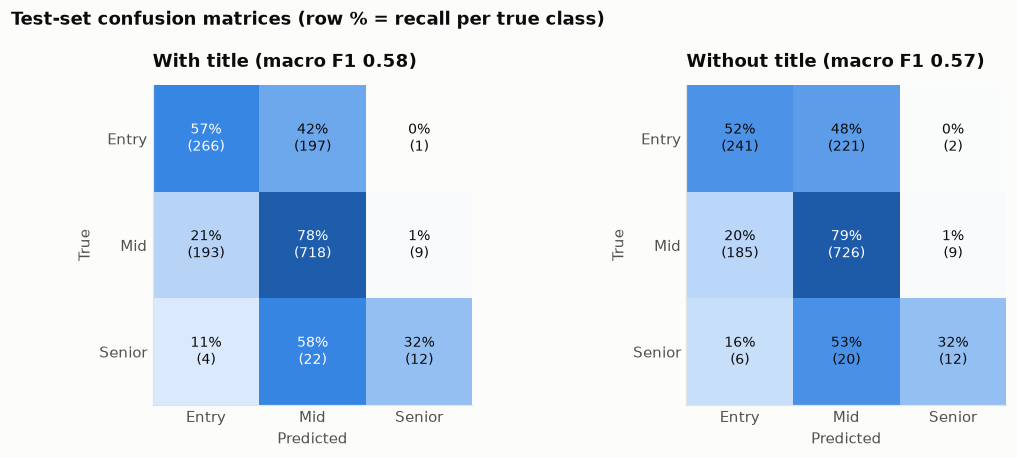

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (label, res) in zip(axes, [("With title", W), ("Without title", NT)]):
    cm = np.array(res["test"]["confusion_matrix"])
    share = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(share, cmap=viz.SEQUENTIAL, vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{share[i, j]:.0%}\n({cm[i, j]})", ha="center", va="center", fontsize=9,
                    color="white" if share[i, j] > 0.55 else viz.TEXT_PRIMARY)
    ax.set_xticks(range(3), CLASSES)
    ax.set_yticks(range(3), CLASSES)
    ax.grid(False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{label} (macro F1 {res['test']['macro_f1']:.2f})")
fig.suptitle("Test-set confusion matrices (row % = recall per true class)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "15_confusion_matrices")
plt.show()

**Takeaway:** Test macro F1 is 0.582, in line with the cross-validated 0.575, so the choices did not overfit to the training folds. Mid is the easy class (F1 0.77). The main confusion is Entry vs. Mid: 42% of Entry postings are predicted Mid, and 21% of Mid postings are predicted Entry. Senior recall is only 32% (12 of 38), but when the model predicts Senior it is right 55% of the time.

## 3. Does the model just read "Senior" in the title?

Same model and hyperparameters, retrained with the title removed from every input: from the TF-IDF text, the skill flags and the keyword flags.

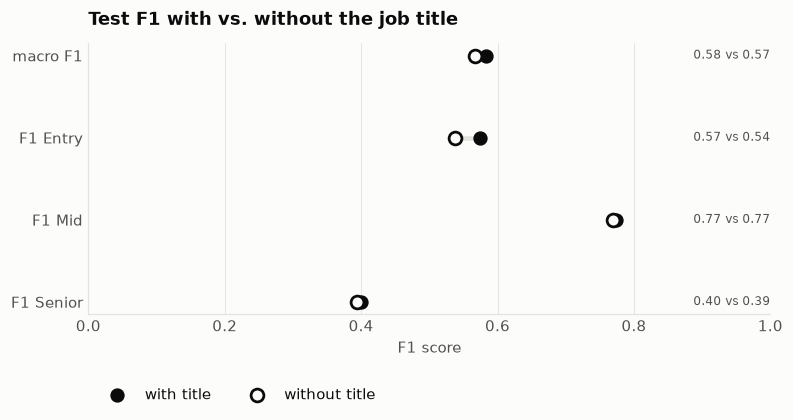

,macro F1,F1 Entry,F1 Mid,F1 Senior
variant,,,,
with title,0.582,0.574,0.773,0.400
without title,0.567,0.538,0.769,0.393


In [6]:
rows = []
for label, res in [("with title", W), ("without title", NT)]:
    pc = res["test"]["per_class"]
    rows.append({"variant": label, "macro F1": res["test"]["macro_f1"], **{f"F1 {c}": pc[c]["f1-score"] for c in CLASSES}})
ablation = pd.DataFrame(rows).set_index("variant")

fig, ax = plt.subplots(figsize=(8, 3.2))
metrics_order = ["macro F1"] + [f"F1 {c}" for c in CLASSES]
y = np.arange(len(metrics_order))
ax.hlines(y, ablation.loc["without title", metrics_order], ablation.loc["with title", metrics_order], color=viz.GRID, linewidth=3)
ax.scatter(ablation.loc["with title", metrics_order], y, s=70, color=viz.TEXT_PRIMARY, zorder=3, label="with title")
ax.scatter(ablation.loc["without title", metrics_order], y, s=70, facecolor=viz.SURFACE, edgecolor=viz.TEXT_PRIMARY,
           linewidth=1.8, zorder=3, label="without title")
for yi, m in zip(y, metrics_order):
    ax.text(1.0, yi, f"{ablation.loc['with title', m]:.2f} vs {ablation.loc['without title', m]:.2f}",
            ha="right", va="center", fontsize=8, color=viz.TEXT_SECONDARY)
ax.set_yticks(y, metrics_order)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Test F1 with vs. without the job title")
ax.set_xlabel("F1 score")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2)
viz.save(fig, "16_title_ablation")
plt.show()
ablation.round(3)

**Takeaway:** Removing the title costs only 0.015 macro F1 on the test set (0.582 → 0.567) and 0.047 in cross-validation (0.575 → 0.528). Entry is hit hardest (F1 0.57 → 0.54), and Senior barely changes. So the model learns mostly from the description (responsibilities, requirements, tone), not just from reading "Senior" in the title.

## 4. What the model learned: SHAP values per class

XGBoost has no per-class coefficients, so we use **SHAP** (TreeExplainer). It splits each prediction into per-feature contributions, one set per class.
For each class and word we take the **average push the word gives when it is present**: the sum of its SHAP values over the postings that contain it, divided by all test postings. This way a frequent, strong signal ranks above a rare one. (A plain mean of signed SHAP values mostly measures the effect of a word being *absent*.) All 1,422 test postings are used, so the 38 Senior ones are included.
Numeric features (years, length, skill count) are summarized separately by mean |SHAP|.

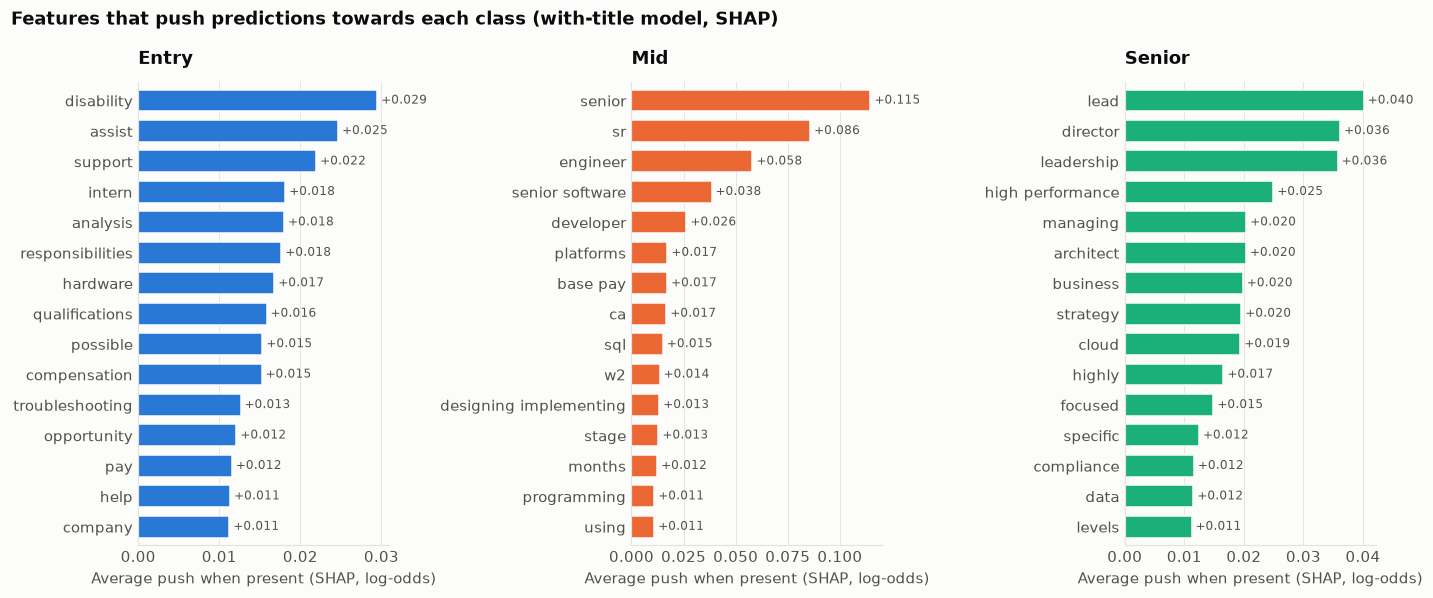

Numeric features, mean |SHAP| per class:


,Entry,Mid,Senior
log_desc_words,0.014,0.026,0.013
years_required,0.236,0.011,0.120
skill_count,0.010,0.001,0.011
missingindicator_years_required,0.000,0.000,0.001


In [7]:
import shap

from src.models.train_classifier import group_split, load_data


def class_shap(full_pipeline, include_title):
    """Per class: average SHAP push of each feature when present, and mean |SHAP|."""
    X, y, groups, _ = load_data(include_title)  # cached features, same split as training
    _, test_idx = group_split(y, groups)
    X_test = X.iloc[test_idx]
    pre, clf = full_pipeline.named_steps["preprocess"], full_pipeline.named_steps["clf"]
    Xt = pre.transform(X_test)
    names = np.array([n.split("__", 1)[1] for n in pre.get_feature_names_out()])
    values = shap.TreeExplainer(clf).shap_values(Xt)  # (rows, features, classes)
    values = np.asarray(values)
    if values.ndim == 3 and values.shape[0] == len(CLASSES):  # older shap: list per class
        values = np.moveaxis(values, 0, -1)
    present = (Xt != 0).toarray() if hasattr(Xt, "toarray") else (Xt != 0)
    push = (values * present[:, :, None]).mean(axis=0)
    return (
        pd.DataFrame(push, index=names, columns=CLASSES),
        pd.DataFrame(np.abs(values).mean(axis=0), index=names, columns=CLASSES),
    )


mean_shap, abs_shap = class_shap(model, include_title=True)
numeric = [n for n in mean_shap.index if n.startswith(("log_desc", "years_required", "skill_count", "missingindicator"))]

fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))
for ax, level in zip(axes, CLASSES):
    top = mean_shap[level].drop(numeric).sort_values(ascending=False).head(15)
    viz.barh(ax, top.index, top.values, color=viz.SENIORITY_COLORS[level], fmt="{:+.3f}")
    ax.set_title(level)
    ax.set_xlabel("Average push when present (SHAP, log-odds)")
fig.suptitle("Features that push predictions towards each class (with-title model, SHAP)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "17_top_features")
plt.show()
print("Numeric features, mean |SHAP| per class:")
abs_shap.loc[numeric].round(3)

In [8]:
# Same view for the model that never sees the title
nt_model = joblib.load(ROOT / "models" / "seniority_notitle.joblib")["pipeline"]
nt_shap, _ = class_shap(nt_model, include_title=False)
pd.DataFrame({level: nt_shap[level].drop(numeric, errors="ignore").sort_values(ascending=False).head(15).index.tolist()
              for level in CLASSES})

,Entry,Mid,Senior
0,assist,senior,lead
1,disability,sr,director
2,hardware,code,managing
3,support,engineer,leadership
4,opportunity,like,strategy
5,possible,base pay,strategic
6,analysis,designing implementing,compliance
7,engineer,using,high performance
8,qualifications,designing,highly
9,compensation,ca,stakeholders


**Takeaway:** The signals make sense. Entry is driven by *support, assist, intern, troubleshooting, hardware*, which fits IT-support roles. Mid is driven by *senior, sr, engineer*, which confirms that LinkedIn's "Mid-Senior level" mixes both levels. Senior is driven by *lead, director, leadership, strategy, managing*. Without the title, the same themes come from the description (*stakeholders, strategic, compliance* for Senior). One caveat: some boilerplate also carries weight. *disability, compensation, pay* push towards Entry because large employers' equal-opportunity and pay-transparency templates are common among their entry postings. This is a leftover template signal, not a seniority signal.

## 5. Error analysis: 20 misclassified test postings (with-title model)

In [9]:
wt = preds[preds["variant"] == "with_title"].copy()
wrong = wt[wt["true"] != wt["pred"]].copy()
prob_cols = [c for c in wt.columns if c.startswith("p_")]
if prob_cols:
    wrong["confidence"] = wrong[prob_cols].max(axis=1).round(2)
print(f"{len(wrong)} of {len(wt)} test postings misclassified ({len(wrong) / len(wt):.1%})")
print(wrong.groupby(["true", "pred"]).size().rename("count").to_string())

# Sample across all error types so rare ones (Senior) are shown too.
sample = wrong.sample(frac=1, random_state=0).groupby(["true", "pred"]).head(4)
sample = sample.sort_values(["true", "pred"]).head(20)
sample["snippet"] = sample["description_clean"].str.slice(0, 160) + "..."
sample[["title", "true", "pred"] + (["confidence"] if prob_cols else []) + ["snippet"]].reset_index(drop=True)

426 of 1422 test postings misclassified (30.0%)
true    pred  
Entry   Mid       197
        Senior      1
Mid     Entry     193
        Senior      9
Senior  Entry       4
        Mid        22


,title,true,pred,confidence,snippet
0,Network Security Engineer / Hybrid Onsite NYC,Entry,Mid,0.89,"Dice is the leading career destination for tech experts at every stage of their careers. Our client, Motion Recruitm..."
1,Dynamics CE Developer,Entry,Mid,0.62,"Dice is the leading career destination for tech experts at every stage of their careers. Our client, Amtex System In..."
2,AI Software Reliability Engineer,Entry,Mid,0.74,"At Lilly, we unite caring with discovery to make life better for people around the world. We are a global healthcare..."
3,Kafka Site Reliability Engineer (SRE),Entry,Mid,0.83,"Dice is the leading career destination for tech experts at every stage of their careers. Our client, Kforce Technolo..."
4,Data Engineering Analyst,Entry,Senior,0.40,Job Description: We are seeking a highly skilled and motivated Data Engineering Analyst to join our dynamic team for...
5,Business Systems Analyst - R&D Operations,Mid,Entry,0.65,Company Description AbbVie's mission is to discover and deliver innovative medicines and solutions that solve seriou...
6,Business Intelligence Developer,Mid,Entry,0.53,"BI Developer 6-Month Contract to HireRemote or Hybrid in Cleveland, OH**Unable to do C2C or Provide Sponsorship** De..."
7,AWS SUBJECT MATTER EXPERT - REMOTE,Mid,Entry,0.57,AWS ENGINEER / SME100% REMOTEMust meet Citizenship requirement's to possibly obtain a clearance Key responsibilities...
8,Dotnet Developer,Mid,Entry,0.66,".NET Full Stack Developer - Contract to Hire - Hybrid (Lansing, MI) Position Overview:We are seeking a skilled .NET ..."
9,Solutions Architect,Mid,Senior,0.68,"Hybrid ROLE Richardson TXAs a Product Consultant Architect, you will play a critical role in identifying new opportu..."


**Patterns in the errors**

- **Senior predicted as Mid (22 of 38 Senior postings):** clearly senior titles such as *Director, Software Engineering*, *VP Data Science* and *Senior Director – Enterprise Data Engineering* get P(Senior) of only 0.1–0.4. With 153 Senior training postings the model is cautious. A lower decision threshold for Senior would trade some precision for recall.
- **Some errors are label noise:** *Python Developer* and *Microsoft Dynamics CRM Developer* are labeled Senior, while *Staff Security Engineer* and *Principal Infrastructure Engineer* are labeled Mid. *Lead Information Security Engineer* is labeled Senior, reposted 4 times, and predicted Entry every time.
- **Entry vs. Mid is often ambiguous:** generic titles such as *Data Engineer*, *Cloud Engineer* and *Network Engineer* appear under both labels. Employers set LinkedIn's level inconsistently.
- **Dice reposts are over-represented:** 18% of errors, vs. 11.5% of test postings, start with Dice's recruiter boilerplate, which buries the actual job text.
- **Near-duplicates survived the dedupe:** 76 test postings share a title and company with another test posting but have slightly different descriptions, so the same error repeats.

## 6. Try it

In [10]:
examples = pd.DataFrame(
    {
        "title": ["Software Engineering Intern", "Staff Backend Engineer", "Director of Data Science"],
        "description": [
            "Summer internship for students pursuing a CS degree. Learn Python and SQL with mentorship.",
            "8+ years building distributed systems in Go and Kubernetes. Lead design reviews and mentor engineers.",
            "Set the data strategy, manage a team of 12 data scientists, and partner with executive stakeholders.",
        ],
    }
)
proba = model.predict_proba(examples)
pd.DataFrame(proba, columns=CLASSES, index=examples["title"]).round(2)

,Entry,Mid,Senior
title,,,
Software Engineering Intern,0.74,0.18,0.08
Staff Backend Engineer,0.15,0.74,0.12
Director of Data Science,0.06,0.05,0.89


## Summary

- **Result:** XGBoost with TF-IDF and hand-crafted features reaches **0.58 test macro F1** (baseline 0.26) on companies it has never seen. Mid F1 is 0.77, Entry 0.57 and Senior 0.40.
- **It reads the description, not just the title:** without the title, macro F1 drops only to 0.57.
- **The ceiling is the labels:** LinkedIn's Mid-Senior bucket, inconsistent Entry labeling and only 191 Senior postings limit what any model can learn. The error analysis shows clear mislabels.
- **Next steps, if there were more time:** tune a Senior-specific decision threshold, remove near-duplicates by title + company, strip job-board boilerplate (Dice), and add a manually labeled validation set.
- **Saved:** `models/seniority.joblib` (with title, used by the app) and `models/seniority_notitle.joblib`. Both accept raw title/description rows. All results are in `reports/metrics.json`.